# ✈️ 항공편 지연 여부 이진분류 - Deep Learning (MLP)

`new_flight_weather_merged.csv`를 이용해 **지연 여부(is_delay)** 를 예측하는 딥러닝(MLP) 이진분류 노트북입니다.

- 시간 기준 Train/Test 분리(미래 정보 누수 방지)
- 수치형: 중앙값 대치
- 범주형: UNKNOWN 대치 + One-Hot
- `arrival_code` 생성(도착지 기반) → **cat_cols에 포함**
- 원핫이 너무 넓으면 TruncatedSVD로 축소 옵션
- ROC-AUC / PR-AUC / Threshold 실험 포함


In [1]:
# =====================================================
# 0) 라이브러리
# =====================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False


from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.decomposition import TruncatedSVD

import tensorflow as tf
import matplotlib.pyplot as plt

np.random.seed(42)
tf.random.set_seed(42)

print("TF version:", tf.__version__)


TF version: 2.10.0


## 1) 데이터 로드

In [2]:
# =====================================================
# 1) 데이터 로드
# =====================================================
# ✅ 경로만 본인 환경에 맞게 수정하세요
csv_path = "data/new_flight_weather_merged.csv"  # 예) "C:/ai/1month/data/new_flight_weather_merged.csv"
df = pd.read_csv(csv_path)

print("✅ CSV 로드 완료")
print("행 수:", len(df), "| 컬럼 수:", df.shape[1])
display(df.head())


C:\Users\Admin\AppData\Local\Temp\ipykernel_14288\2158547541.py:6: DtypeWarning: Columns (31,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


✅ CSV 로드 완료
행 수: 2836872 | 컬럼 수: 55


,Unnamed: 0,출발/도착,공항명,항공사,편명,도착지,일자,계획시간,예상시간,출발시간,...,현상번호(국내식),지면온도(°C),풍속_ms,풍향_deg,시정_m,전운량_okta,1층 운고(FT)_결측여부,운형(운형약어),최저운고(100m ),weather_datetime
0,5729485,출발,인천,홍콩항공,HX623,홍콩,20180101,5.0,2340.0,0.0,...,0.0,NaN,0.514444,30.0,10000.0,0.0,NaN,NaN,NaN,2018-01-01 01:00:00
1,5729484,출발,인천,에미레이트항공,EK323,두바이,20180101,5.0,2350.0,6.0,...,0.0,NaN,0.514444,30.0,10000.0,0.0,NaN,NaN,NaN,2018-01-01 01:00:00
2,5729487,출발,인천,에티하드,EY873,아부다비,20180101,15.0,15.0,14.0,...,0.0,NaN,0.514444,30.0,10000.0,0.0,NaN,NaN,NaN,2018-01-01 01:00:00
3,5729488,출발,인천,타이에어아시아엑스,XJ703,돈므앙(방콕),20180101,20.0,20.0,25.0,...,0.0,NaN,0.514444,30.0,10000.0,0.0,NaN,NaN,NaN,2018-01-01 01:00:00
4,5729486,출발,인천,싱가폴항공,SQ603,싱가포르,20180101,5.0,0.0,28.0,...,0.0,NaN,0.514444,30.0,10000.0,0.0,NaN,NaN,NaN,2018-01-01 01:00:00


## 2) 타깃(is_delay) 준비

In [3]:
# =====================================================
# 2) 타깃(is_delay) 준비
# =====================================================
# - 이미 is_delay가 있으면 그대로 사용
# - 없으면 상태 컬럼으로 생성 (상태 == '지연'이면 1)
if "is_delay" not in df.columns:
    if "상태" not in df.columns:
        raise KeyError("❌ 'is_delay'도 없고 '상태'도 없습니다. 타깃 컬럼을 확인하세요.")
    df["is_delay"] = (df["상태"] == "지연").astype(int)

print("✅ is_delay 분포")
display(df["is_delay"].value_counts(dropna=False).to_frame("count"))


✅ is_delay 분포


,count
0,2354459
1,482413


## 3) arrival_code 생성 (cat_cols에 포함)

- 도착지가 숫자형이면 to_numeric 기반
- 문자형(예: ICN/GMP)이면 category.codes 기반
- cat 파이프라인의 UNKNOWN 처리와 충돌 없게 **문자열(str)** 로 고정


In [4]:
# =====================================================
# 3) arrival_code 생성 (cat_cols에 넣을 거라 str로 고정)
# =====================================================
if "arrival_code" in df.columns:
    tmp = pd.to_numeric(df["arrival_code"], errors="coerce")
    df["arrival_code"] = tmp.fillna(-1).astype(int).astype(str)

elif "도착지" in df.columns:
    tmp = pd.to_numeric(df["도착지"], errors="coerce")
    if tmp.notna().mean() > 0.7:
        df["arrival_code"] = tmp.fillna(-1).astype(int).astype(str)
    else:
        df["arrival_code"] = df["도착지"].astype("category").cat.codes.astype(int).astype(str)
else:
    # 도착지/arrival_code 둘 다 없다면 안전장치
    df["arrival_code"] = "-1"

print("✅ arrival_code 예시")
if "도착지" in df.columns:
    display(df[["도착지"]].assign(arrival_code=df["arrival_code"]).head(10))
else:
    display(df[["arrival_code"]].head(10))


✅ arrival_code 예시


,도착지,arrival_code
0,홍콩,-1
1,두바이,-1
2,아부다비,-1
3,돈므앙(방콕),-1
4,싱가포르,-1
5,싱가포르,-1
6,아타튀르크,-1
7,도하,-1
8,암스테르담,-1
9,깜라인(나트랑),-1


## 4) Feature 컬럼 정의

In [5]:
# =====================================================
# 4) Feature 정의
# =====================================================
# 🔢 수치형 변수(고정)
num_cols = [
    "기온(°C)",
    "풍속_ms",
    "dep_hour",
    "dep_weekday",
    "is_weekend",
]

# 🏷 범주형 변수 (✅ arrival_code 포함)
cat_cols = [
    "항공사",
    "출발지",
    "flight_type",
    "arrival_code",
]

# 실제 존재하는 컬럼만 사용
num_cols = [c for c in num_cols if c in df.columns]
cat_cols = [c for c in cat_cols if c in df.columns]

X_cols = num_cols + cat_cols
if not X_cols:
    raise ValueError("❌ X_cols가 비었습니다. num_cols/cat_cols 컬럼명이 CSV와 일치하는지 확인하세요.")

print("✅ num_cols:", num_cols)
print("✅ cat_cols:", cat_cols)
print("✅ X_cols:", X_cols)


✅ num_cols: ['기온(°C)', '풍속_ms', 'dep_hour', 'dep_weekday', 'is_weekend']
✅ cat_cols: ['항공사', '출발지', 'flight_type', 'arrival_code']
✅ X_cols: ['기온(°C)', '풍속_ms', 'dep_hour', 'dep_weekday', 'is_weekend', '항공사', '출발지', 'flight_type', 'arrival_code']


## 5) 시간 기준 Train/Test 분리

In [6]:
# =====================================================
# 5) 시간 기준 Train/Test 분리
# =====================================================
if "departure_datetime" not in df.columns:
    raise KeyError("❌ 'departure_datetime' 컬럼이 없습니다.")

df["departure_datetime"] = pd.to_datetime(df["departure_datetime"], errors="coerce")
df = df[df["departure_datetime"].notna()].copy()
df = df.sort_values("departure_datetime")

split_date = df["departure_datetime"].quantile(0.8)

train_df = df[df["departure_datetime"] <= split_date]
test_df  = df[df["departure_datetime"] > split_date]

X_train = train_df[X_cols]
y_train = train_df["is_delay"].astype(int)

X_test  = test_df[X_cols]
y_test  = test_df["is_delay"].astype(int)

print("📦 데이터 분리")
print("Train:", len(train_df), "Test:", len(test_df))
print("Train positive rate:", y_train.mean())
print("Test  positive rate:", y_test.mean())


📦 데이터 분리
Train: 2269498 Test: 567374
Train positive rate: 0.14812438697897068
Test  positive rate: 0.2577576695442512


## 6) 전처리

In [7]:
# =====================================================
# 6) 전처리 파이프라인
# =====================================================
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="UNKNOWN")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

transformers = []
if num_cols:
    transformers.append(("num", num_pipeline, num_cols))
if cat_cols:
    transformers.append(("cat", cat_pipeline, cat_cols))

preprocessor = ColumnTransformer(transformers)

X_train_pp = preprocessor.fit_transform(X_train)
X_test_pp  = preprocessor.transform(X_test)

print("전처리 후 shape:", X_train_pp.shape)


전처리 후 shape: (2269498, 155)


## 7) 희소행렬 처리 (옵션: SVD 축소)

In [8]:
# =====================================================
# 7) 희소행렬 처리 (옵션: SVD 축소)
# =====================================================
USE_SVD_IF_WIDE = True
SVD_THRESHOLD = 20000
SVD_COMPONENTS = 512

svd = None

if USE_SVD_IF_WIDE and X_train_pp.shape[1] > SVD_THRESHOLD:
    print(f"[INFO] 특성 개수({X_train_pp.shape[1]})가 커서 TruncatedSVD({SVD_COMPONENTS})로 축소합니다.")
    svd = TruncatedSVD(n_components=SVD_COMPONENTS, random_state=42)
    X_train_pp = svd.fit_transform(X_train_pp)
    X_test_pp  = svd.transform(X_test_pp)
else:
    if hasattr(X_train_pp, "toarray"):
        X_train_pp = X_train_pp.toarray()
        X_test_pp  = X_test_pp.toarray()

X_train_pp = X_train_pp.astype(np.float32)
X_test_pp  = X_test_pp.astype(np.float32)

y_train_np = y_train.values.astype(np.float32)
y_test_np  = y_test.values.astype(np.float32)

print("학습 입력 shape:", X_train_pp.shape)


학습 입력 shape: (2269498, 155)


## 8) Class Weight (불균형 대응)

In [9]:
# =====================================================
# 8) class_weight 계산
# =====================================================
classes = np.array([0, 1])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train.values)
class_weight = {0: float(weights[0]), 1: float(weights[1])}

print("✅ class_weight:", class_weight)


✅ class_weight: {0: 0.5869401498968102, 1: 3.3755413959686824}


## 9) 딥러닝(MLP) 이진분류 모델

In [10]:
# =====================================================
# 9) 모델 정의 / 학습
# =====================================================
input_dim = X_train_pp.shape[1]

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(input_dim,)),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="acc"),
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ],
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=8, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max", factor=0.5, patience=4, min_lr=1e-6),
]

history = model.fit(
    X_train_pp, y_train_np,
    validation_data=(X_test_pp, y_test_np),
    epochs=200,
    batch_size=256,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/200
8866/8866 [==============================] - 31s 3ms/step - loss: 0.6427 - acc: 0.5688 - auc: 0.6729 - precision: 0.2125 - recall: 0.7061 - val_loss: 0.6435 - val_acc: 0.5772 - val_auc: 0.6728 - val_precision: 0.3488 - val_recall: 0.7386 - lr: 0.0010
Epoch 2/200
8866/8866 [==============================] - 29s 3ms/step - loss: 0.6300 - acc: 0.5785 - auc: 0.6918 - precision: 0.2200 - recall: 0.7254 - val_loss: 0.6243 - val_acc: 0.5947 - val_auc: 0.6734 - val_precision: 0.3554 - val_recall: 0.7034 - lr: 0.0010
Epoch 3/200
8866/8866 [==============================] - 29s 3ms/step - loss: 0.6257 - acc: 0.5843 - auc: 0.6981 - precision: 0.2231 - recall: 0.7276 - val_loss: 0.6186 - val_acc: 0.6055 - val_auc: 0.6718 - val_precision: 0.3578 - val_recall: 0.6674 - lr: 0.0010
Epoch 4/200
8866/8866 [==============================] - 29s 3ms/step - loss: 0.6218 - acc: 0.5953 - auc: 0.7039 - precision: 0.2276 - recall: 0.7238 - val_loss: 0.6157 - val_acc: 0.6179 - val_auc: 0.6773 - val_

## 10) 평가

In [11]:
# =====================================================
# 10) 평가
# =====================================================
y_prob = model.predict(X_test_pp, batch_size=512).reshape(-1)
y_pred = (y_prob >= 0.5).astype(int)

print("📊 기본 성능 (threshold=0.5)")
print(classification_report(y_test_np, y_pred, digits=4))

print("ROC-AUC:", roc_auc_score(y_test_np, y_prob))
print("PR-AUC :", average_precision_score(y_test_np, y_prob))
print("Confusion Matrix:")
print(confusion_matrix(y_test_np, y_pred))


1109/1109 [==============================] - 1s 1ms/step
📊 기본 성능 (threshold=0.5)
              precision    recall  f1-score   support

         0.0     0.8340    0.6478    0.7292    421129
         1.0     0.3826    0.6286    0.4757    146245

    accuracy                         0.6428    567374
   macro avg     0.6083    0.6382    0.6024    567374
weighted avg     0.7176    0.6428    0.6638    567374

ROC-AUC: 0.6958415937130592
PR-AUC : 0.4254975797281794
Confusion Matrix:
[[272800 148329]
 [ 54317  91928]]


## 11) Threshold 실험

In [12]:
# =====================================================
# 11) Threshold 실험
# =====================================================
for t in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    y_pred_t = (y_prob >= t).astype(int)
    print(f"\n===== Threshold = {t:.1f} =====")
    print(classification_report(y_test_np, y_pred_t, digits=4))



===== Threshold = 0.2 =====
              precision    recall  f1-score   support

         0.0     0.9293    0.1926    0.3191    421129
         1.0     0.2918    0.9578    0.4473    146245

    accuracy                         0.3898    567374
   macro avg     0.6106    0.5752    0.3832    567374
weighted avg     0.7650    0.3898    0.3521    567374


===== Threshold = 0.3 =====
              precision    recall  f1-score   support

         0.0     0.9023    0.3295    0.4827    421129
         1.0     0.3173    0.8973    0.4688    146245

    accuracy                         0.4759    567374
   macro avg     0.6098    0.6134    0.4758    567374
weighted avg     0.7515    0.4759    0.4791    567374


===== Threshold = 0.4 =====
              precision    recall  f1-score   support

         0.0     0.8744    0.4672    0.6090    421129
         1.0     0.3446    0.8068    0.4830    146245

    accuracy                         0.5548    567374
   macro avg     0.6095    0.6370    0.54

## 12) 학습 곡선

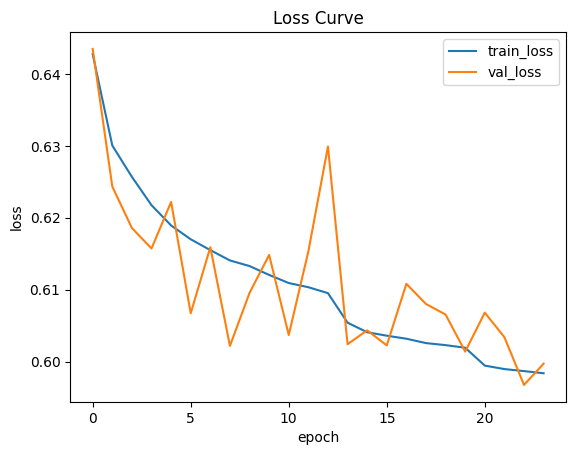

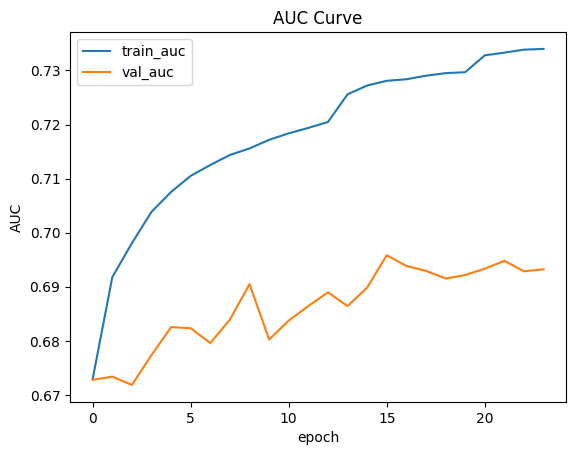

In [13]:
# =====================================================
# 12) 학습 곡선
# =====================================================
plt.figure()
plt.plot(history.history.get("loss", []), label="train_loss")
plt.plot(history.history.get("val_loss", []), label="val_loss")
plt.xlabel("epoch"); plt.ylabel("loss")
plt.legend(); plt.title("Loss Curve")
plt.show()

plt.figure()
plt.plot(history.history.get("auc", []), label="train_auc")
plt.plot(history.history.get("val_auc", []), label="val_auc")
plt.xlabel("epoch"); plt.ylabel("AUC")
plt.legend(); plt.title("AUC Curve")
plt.show()


## 13) (선택) 저장

In [14]:
# =====================================================
# 13) (선택) 저장
# =====================================================
# import joblib
# joblib.dump(preprocessor, "preprocessor.joblib")
# if svd is not None:
#     joblib.dump(svd, "svd.joblib")
# model.save("dl_binary_delay_model.keras")
# print("✅ 저장 완료")
